In [1]:
import pandas as pd

from orion.data import load_signal

# 1. Data

In [2]:
data_name = 'smap'
signal_name = 'S-1'

data = load_signal('multivariate/' + signal_name)

data.head()

,timestamp,0,1,2,3,4,5,6,7,8,...,15,16,17,18,19,20,21,22,23,24
0,1222819200,-0.366359,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1222840800,-0.394108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1222862400,0.403625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1222884000,-0.362759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1222905600,-0.370746,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 2. Pipeline

In [3]:
from mlblocks import MLPipeline

pipeline_name = 'lstm_autoencoder'

pipeline = MLPipeline(pipeline_name)
pipeline.primitives


['mlstars.custom.timeseries_preprocessing.time_segments_aggregate',
 'sklearn.impute.SimpleImputer',
 'sklearn.preprocessing.MinMaxScaler',
 'mlstars.custom.timeseries_preprocessing.rolling_window_sequences',
 'orion.primitives.timeseries_preprocessing.slice_array_by_dims',
 'mod.keras.Sequential.LSTMSeq2Seq',
 'orion.primitives.timeseries_errors.reconstruction_errors',
 'orion.primitives.timeseries_anomalies.find_anomalies']

In [4]:
import json

with open(f'../../orion/pipelines/verified/{pipeline_name}/{pipeline_name}_{data_name}.json') as f:
    hyperparameters = json.load(f)

print(hyperparameters)

{'mlstars.custom.timeseries_preprocessing.time_segments_aggregate#1': {'time_column': 'timestamp', 'interval': 21600}, 'mlstars.custom.timeseries_preprocessing.rolling_window_sequences#1': {'target_column': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]}, 'orion.primitives.timeseries_preprocessing.slice_array_by_dims#1': {'target_index': 0, 'axis': 2}, 'mod.keras.Sequential.LSTMSeq2Seq#1': {'input_shape': [100, 25], 'target_shape': [100, 1]}}


In [5]:
# hyperparameters = {
#     "mlstars.custom.timeseries_preprocessing.rolling_window_sequences#1": {
#         'target_column': list(range(data.shape[1] - 1))
#     },
#     'orion.primitives.timeseries_preprocessing.slice_array_by_dims#1': {
#         'target_index':0, # list(range(data.shape[1] - 1)),
#         'axis': 2
#     },
#     'mod.keras.Sequential.LSTMSeq2Seq#1': {
#         'input_shape': [100, 25],
#         'target_shape': [100, 1],
#         'epochs': 5,
#         'verbose': True,
#     }
# }

hyperparameters['mlstars.custom.timeseries_preprocessing.rolling_window_sequences#1']['target_column'] = list(range(data.shape[1] - 1))
hyperparameters['orion.primitives.timeseries_preprocessing.slice_array_by_dims#1']['target_index'] = list(range(data.shape[1] - 1))
hyperparameters['orion.primitives.timeseries_preprocessing.slice_array_by_dims#1']['axis'] = 2

hyperparameters['mod.keras.Sequential.LSTMSeq2Seq#1']['epochs'] = 5
hyperparameters['mod.keras.Sequential.LSTMSeq2Seq#1']['verbose'] = True
hyperparameters['mod.keras.Sequential.LSTMSeq2Seq#1']['target_shape'] = [100, 25]

pipeline.set_hyperparameters(hyperparameters)

## step by step execution

MLPipelines are compose of a squence of primitives, these primitives apply tranformation and calculation operations to the data and updates the variables within the pipeline. To view the primitives used by the pipeline, we access its `primtivies` attribute. 

The `lstm_dynamic_threshold` contains 7 primitives. we will observe how the `context` (which are the variables held within the pipeline) are updated after the execution of each primitive.

In [6]:
pipeline.primitives

['mlstars.custom.timeseries_preprocessing.time_segments_aggregate',
 'sklearn.impute.SimpleImputer',
 'sklearn.preprocessing.MinMaxScaler',
 'mlstars.custom.timeseries_preprocessing.rolling_window_sequences',
 'orion.primitives.timeseries_preprocessing.slice_array_by_dims',
 'mod.keras.Sequential.LSTMSeq2Seq',
 'orion.primitives.timeseries_errors.reconstruction_errors',
 'orion.primitives.timeseries_anomalies.find_anomalies']

### time segments aggregate
this primitive creates an equi-spaced time series by aggregating values over fixed specified interval.

* **input**: `X` which is an n-dimensional sequence of values.
* **output**:
    - `X` sequence of aggregated values, one column for each aggregation method.
    - `index` sequence of index values (first index of each aggregated segment).

In [7]:
context = pipeline.fit(data, output_=0)
context.keys()

dict_keys(['X', 'index'])

In [8]:
for i, x in list(zip(context['index'], context['X']))[:5]:
    print("entry at {} has value {}".format(i, x))

entry at 1222819200 has value [-0.36635895  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ]
entry at 1222840800 has value [-0.39410778  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ]
entry at 1222862400 has value [0.4036246 0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.       ]
entry at 1222884000 has value [-0.36275906  0.          0.          0.          0.          0.
  0.          0.          0.     

### SimpleImputer
this primitive is an imputation transformer for filling missing values.
* **input**: `X` which is an n-dimensional sequence of values.
* **output**: `X` which is a transformed version of X.

In [9]:
step = 1

context = pipeline.fit(**context, output_=step, start_=step)
context.keys()

/opt/anaconda3/envs/orion-py11/lib/python3.11/site-packages/sklearn/impute/_base.py:356: FutureWarning: The 'verbose' parameter was deprecated in version 1.1 and will be removed in 1.3. A warning will always be raised upon the removal of empty columns in the future version.
  warnings.warn(


dict_keys(['index', 'X'])

### MinMaxScaler
this primitive transforms features by scaling each feature to a given range.
* **input**: `X` the data used to compute the per-feature minimum and maximum used for later scaling along the features axis.
* **output**: `X` which is a transformed version of X.

In [10]:
step = 2

context = pipeline.fit(**context, output_=step, start_=step)
context.keys()

dict_keys(['index', 'X'])

In [11]:
# after scaling the data between [-1, 1]
# in this example, no change is observed
# since the data was pre-handedly scaled

for i, x in list(zip(context['index'], context['X']))[:5]:
    print("entry at {} has value {}".format(i, x))

entry at 1222819200 has value [-0.36635895 -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.        ]
entry at 1222840800 has value [-0.39410778 -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.         -1.         -1.         -1.         -1.         -1.
 -1.        ]
entry at 1222862400 has value [ 0.4036246 -1.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.
 -1.       ]
entry at 1222884000 has value [-0.36275906 -1.         -1.         -1.         -1.         -1.
 -1.         -

### rolling window sequence
this primitive generates many sub-sequences of the original sequence. it uses a rolling window approach to create the sub-sequences out of time series data.

* **input**: 
    - `X` n-dimensional sequence to iterate over.
    - `index` array containing the index values of X.
* **output**:
    - `X` input sequences.
    - `y` target sequences.
    - `index` first index value of each input sequence.
    - `target_index` first index value of each target sequence.

In [12]:
step = 3

context = pipeline.fit(**context, output_=step, start_=step)
context.keys()

dict_keys(['index', 'X', 'y', 'X_index', 'y_index'])

In [13]:
# after slicing X into multiple sub-sequences
# we obtain a 3 dimensional matrix X where
# the shape indicates (# slices, window size, 1)
# and similarly y is (# slices, target size)

print("X shape = {}\ny shape = {}\nX_index shape = {}\ny_index shape = {}".format(
    context['X'].shape, context['y'].shape, context['X_index'].shape, context['y_index'].shape))

X shape = (10049, 100, 25)
y shape = (10049, 1, 25)
X_index shape = (10049,)
y_index shape = (10049,)


### slice_array_by_dims
this primitive slices an array by specified dimensions.
* **input**: 
    - `y` 3d target sequences.
    - `axis` 1.
* **output**:
    - `y` 2d target sequences.

In [14]:
step = 4

context = pipeline.fit(**context, output_=step, start_=step)
context.keys()

dict_keys(['index', 'X_index', 'y_index', 'X', 'y'])

In [15]:
context['y'].shape

(10049, 100, 25)

In [16]:
print("X shape = {}\ny shape = {}\nX_index shape = {}\ny_index shape = {}".format(
    context['X'].shape, context['y'].shape, context['X_index'].shape, context['y_index'].shape))

X shape = (10049, 100, 25)
y shape = (10049, 100, 25)
X_index shape = (10049,)
y_index shape = (10049,)


### LSTMSeq2Seq
this is a prediction model with double stacked LSTM layers used as a time series regressor. you can read more about it in the [related paper](https://arxiv.org/pdf/1802.04431.pdf).

* **input**: 
    - `X` n-dimensional array containing the input sequences for the model.
    - `y` n-dimensional array containing the target sequences for the model.
* **output**: `y_hat` predicted values.

In [17]:
pipeline.get_hyperparameters()['mod.keras.Sequential.LSTMSeq2Seq#1']

{'classification': False,
 'verbose': True,
 'callbacks': [{'class': 'tensorflow.keras.callbacks.EarlyStopping',
   'args': {'monitor': 'val_loss', 'patience': 10, 'min_delta': 0.0003}}],
 'validation_split': 0.2,
 'batch_size': 64,
 'window_size': 100,
 'input_shape': [100, 25],
 'target_shape': [100, 25],
 'dense_units': 1,
 'optimizer': 'tensorflow.keras.optimizers.Adam',
 'loss': 'tensorflow.keras.losses.mean_squared_error',
 'metrics': ['mse'],
 'epochs': 5,
 'return_sequences': False,
 'layers': [{'class': 'tensorflow.keras.layers.LSTM',
   'parameters': {'input_shape': 'input_shape', 'units': 60}},
  {'class': 'tensorflow.keras.layers.RepeatVector',
   'parameters': {'n': 'window_size'}},
  {'class': 'tensorflow.keras.layers.LSTM',
   'parameters': {'units': 60, 'return_sequences': True}},
  {'class': 'tensorflow.keras.layers.TimeDistributed',
   'parameters': {'layer': {'class': 'tensorflow.keras.layers.Dense',
     'parameters': {'units': 'dense_units'}}}},
  {'class': 'tensor

In [18]:
step = 5

context = pipeline.fit(**context, output_=step, start_=step)
context.keys()

Epoch 1/5
126/126 [==============================] - 10s 62ms/step - loss: 0.1273 - mse: 0.1273 - val_loss: 0.0245 - val_mse: 0.0245
Epoch 2/5
126/126 [==============================] - 7s 57ms/step - loss: 0.0829 - mse: 0.0829 - val_loss: 0.0231 - val_mse: 0.0231
Epoch 3/5
126/126 [==============================] - 7s 58ms/step - loss: 0.0820 - mse: 0.0820 - val_loss: 0.0220 - val_mse: 0.0220
Epoch 4/5
126/126 [==============================] - 7s 58ms/step - loss: 0.0816 - mse: 0.0816 - val_loss: 0.0214 - val_mse: 0.0214
Epoch 5/5
158/158 [==============================] - 3s 18ms/step


dict_keys(['index', 'X_index', 'y_index', 'X', 'y', 'y_hat'])

In [19]:
for i, y, y_hat in list(zip(context['y_index'], context['y'], context['y_hat']))[:5]:
    print("entry at {} has value {}, predicted value {}".format(i, y.shape, y_hat.shape))

entry at 1224979200 has value (100, 25), predicted value (100, 25)
entry at 1225000800 has value (100, 25), predicted value (100, 25)
entry at 1225022400 has value (100, 25), predicted value (100, 25)
entry at 1225044000 has value (100, 25), predicted value (100, 25)
entry at 1225065600 has value (100, 25), predicted value (100, 25)


In [20]:
x = pipeline.blocks['mod.keras.Sequential.LSTMSeq2Seq#1']
x.instance.kwargs


{'dense_units': 25}

In [21]:
x = pipeline.blocks['mod.keras.Sequential.LSTMSeq2Seq#1']
x.instance.model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60)                20640     
                                                                 
 repeat_vector (RepeatVecto  (None, 100, 60)           0         
 r)                                                              
                                                                 
 lstm_1 (LSTM)               (None, 100, 60)           29040     
                                                                 
 time_distributed (TimeDist  (None, 100, 25)           1525      
 ributed)                                                        
                                                                 
 reshape (Reshape)           (None, 100, 25)           0         
                                                                 
Total params: 51205 (200.02 KB)
Trainable params: 51205 

### regression errors

this primitive computes an array of absolute errors comparing predictions and expected output. Optionally smooth them using EWMA.

* **input**: 
    - `y` ground truth.
    - `y_hat` predicted values.
* **output**: `errors` array of errors.

In [22]:
step = 6

context = pipeline.fit(**context, output_=step, start_=step)
context.keys()

true shape = (10148, 25)


dict_keys(['index', 'X_index', 'y_index', 'y_hat', 'X', 'y', 'errors', 'predictions'])

In [23]:
for i, e in list(zip(context['y_index'], context['errors']))[:5]:
    print("entry at {} has error value {:.3f}".format(i, e))

entry at 1224979200 has error value 2.780
entry at 1225000800 has error value 2.758
entry at 1225022400 has error value 2.731
entry at 1225044000 has error value 2.706
entry at 1225065600 has error value 2.681


In [24]:
context['errors'].shape

(10148,)

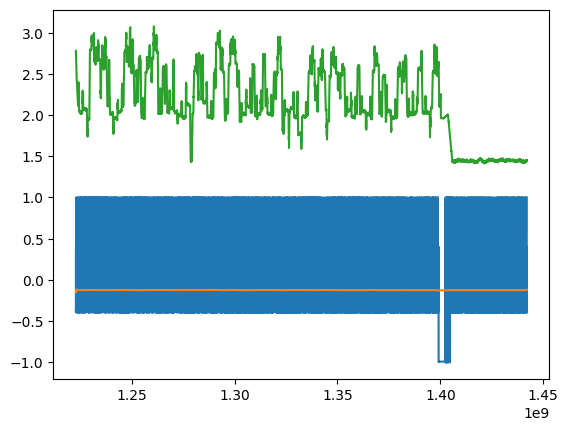

In [25]:
import matplotlib.pyplot as plt
import numpy as np
y = context['y']

true = [item[0] for item in y]
for item in y[-1][1:]:
    true.append(item)

true = np.array(true)

i = 0
plt.plot(context['index'][1:], true[:, i])
plt.plot(context['index'][1:], context['predictions'][:, i])
plt.plot(context['index'][1:], context['errors'])

### find anomalies
this primitive extracts anomalies from sequences of errors following the approach explained in the [related paper](https://arxiv.org/pdf/1802.04431.pdf).

* **input**: 
    - `errors` array of errors.
    - `target_index` array of indices of errors.
* **output**: `y` array containing start-index, end-index, score for each anomalous sequence that was found.

In [26]:
step = 7

context = pipeline.fit(**context, output_=step, start_=step)
context.keys()

dict_keys(['index', 'X_index', 'y_index', 'y_hat', 'errors', 'predictions', 'X', 'y'])

In [27]:
context['y']

array([], dtype=float64)

In [28]:
pd.DataFrame(context['y'], columns=['start', 'end', 'severity'])

ValueError: Empty data passed with indices specified.